<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>ML</b></center>

<center><b><h1>Lab - 10</b></center>    
<pre>    

# Step 1: Import Libraries
This step imports all necessary libraries for data processing, visualization, and machine learning.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.neighbors import KNeighborsClassifier

# Step 2: Load the Dataset
Load Given dataset -  heart.csv

In [4]:
df = pd.read_csv("heart.csv")

# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(723)

# Step 4: Univariate Analysis
Here we visualize the distribution of each feature using histograms.

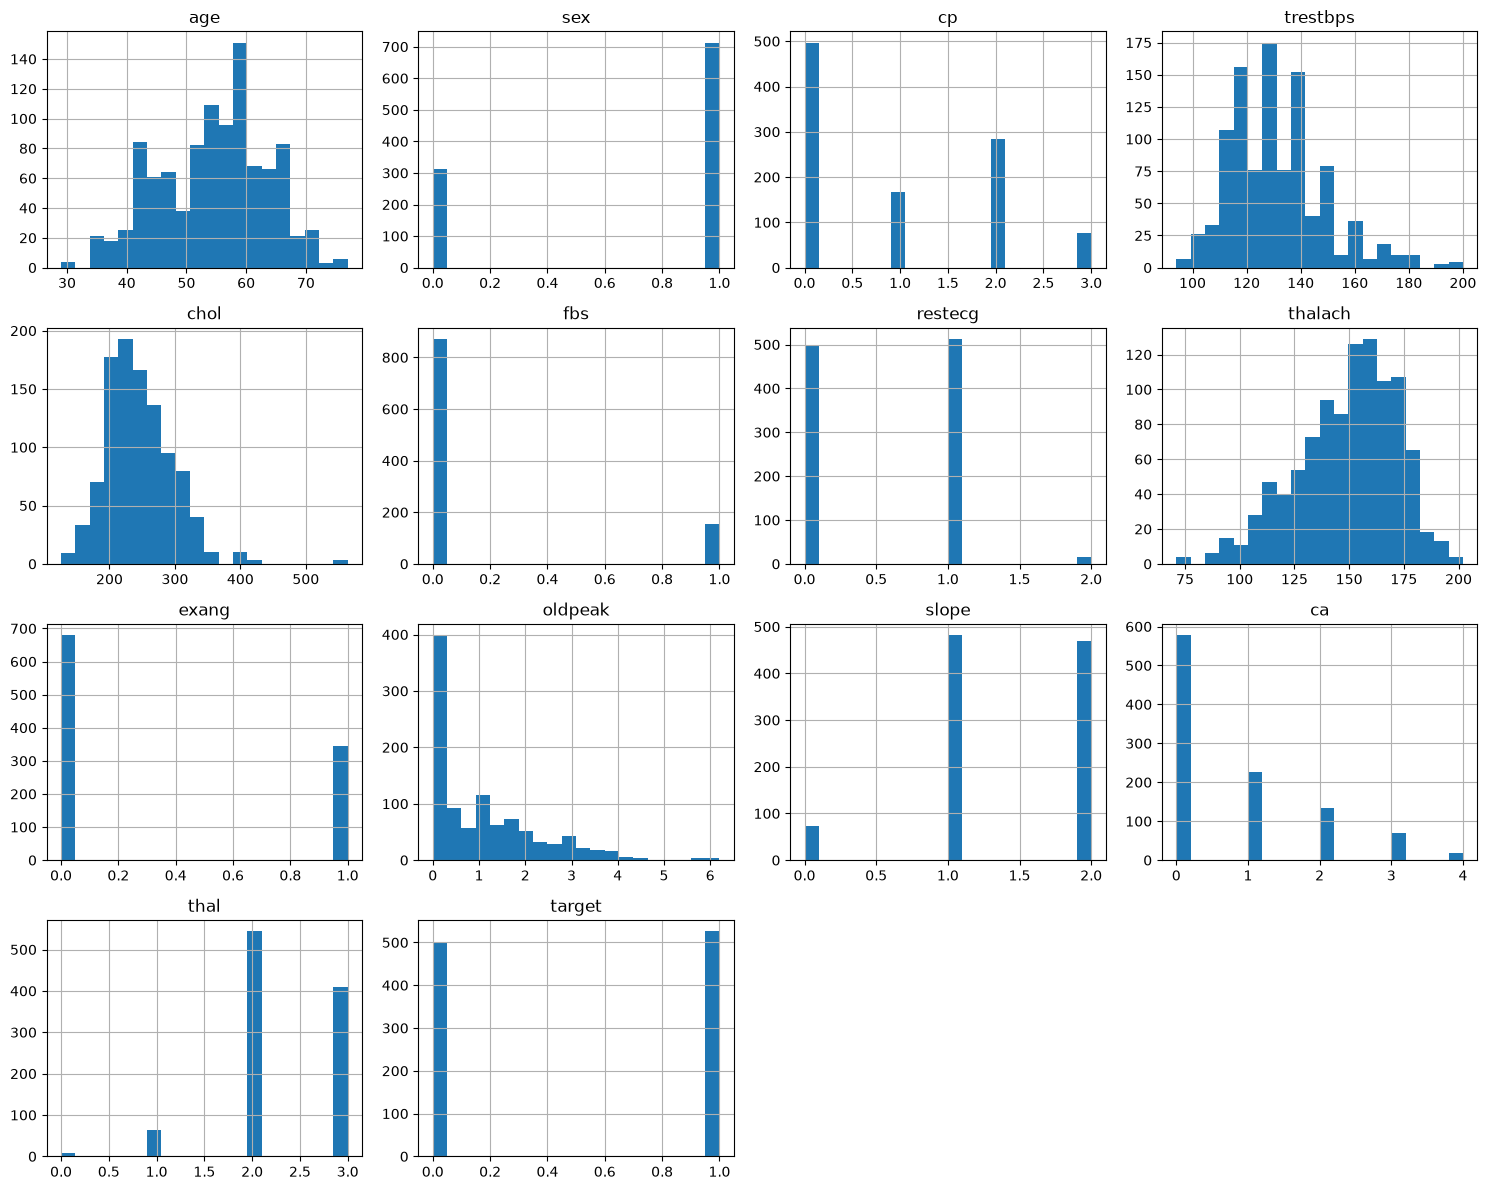

In [9]:
df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

# Step 5: Bivariate Analysis
This step involves exploring the correlations between features using a heatmap.

In [10]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


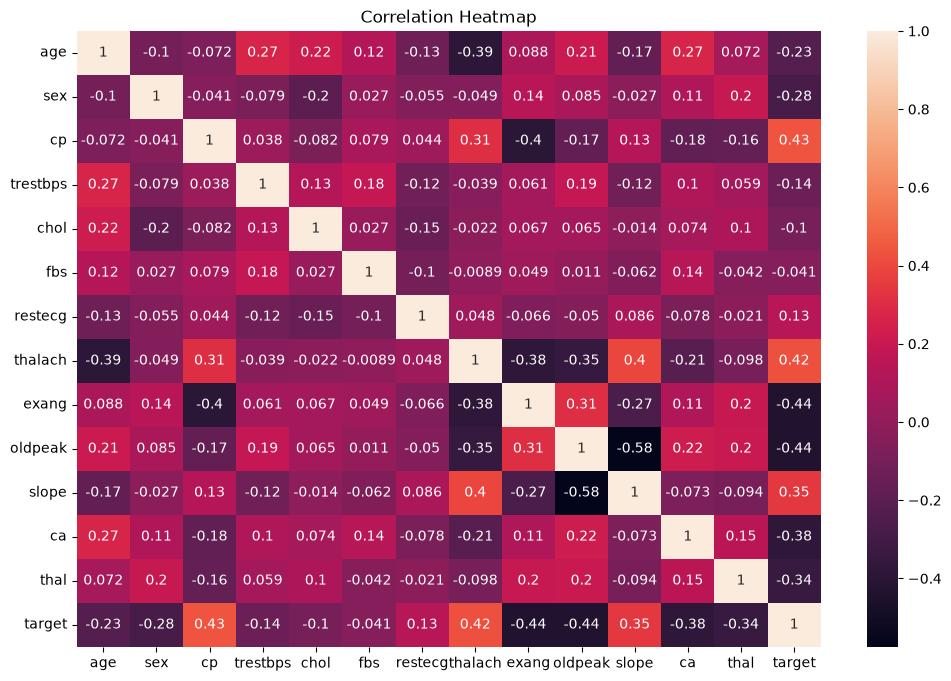

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

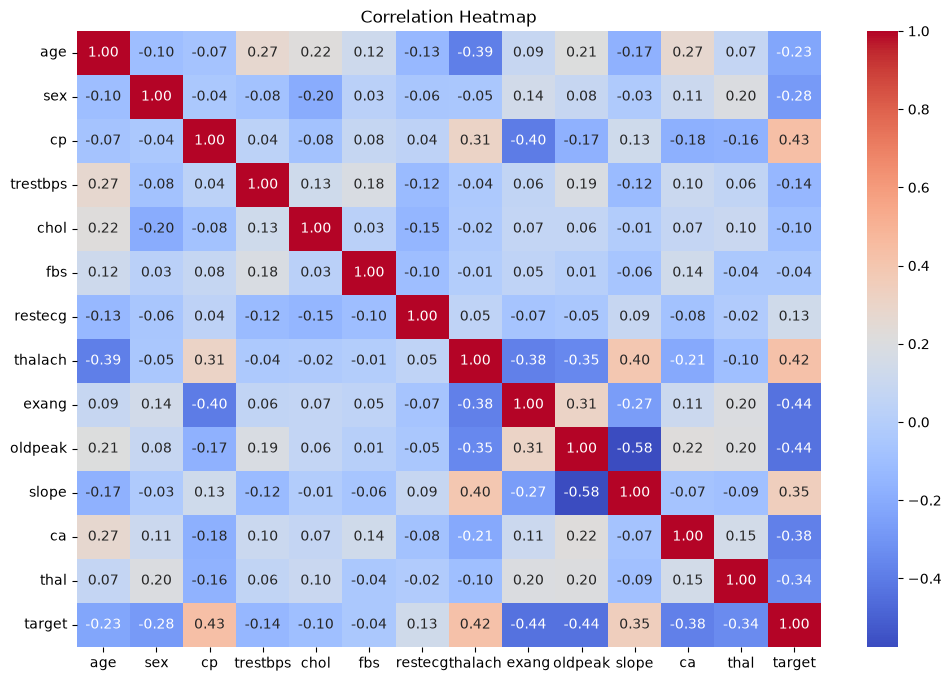

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt = ".2f")

plt.title("Correlation Heatmap")
plt.show()

# Step 6: Outlier Detection
We visualize potential outliers using boxplots.

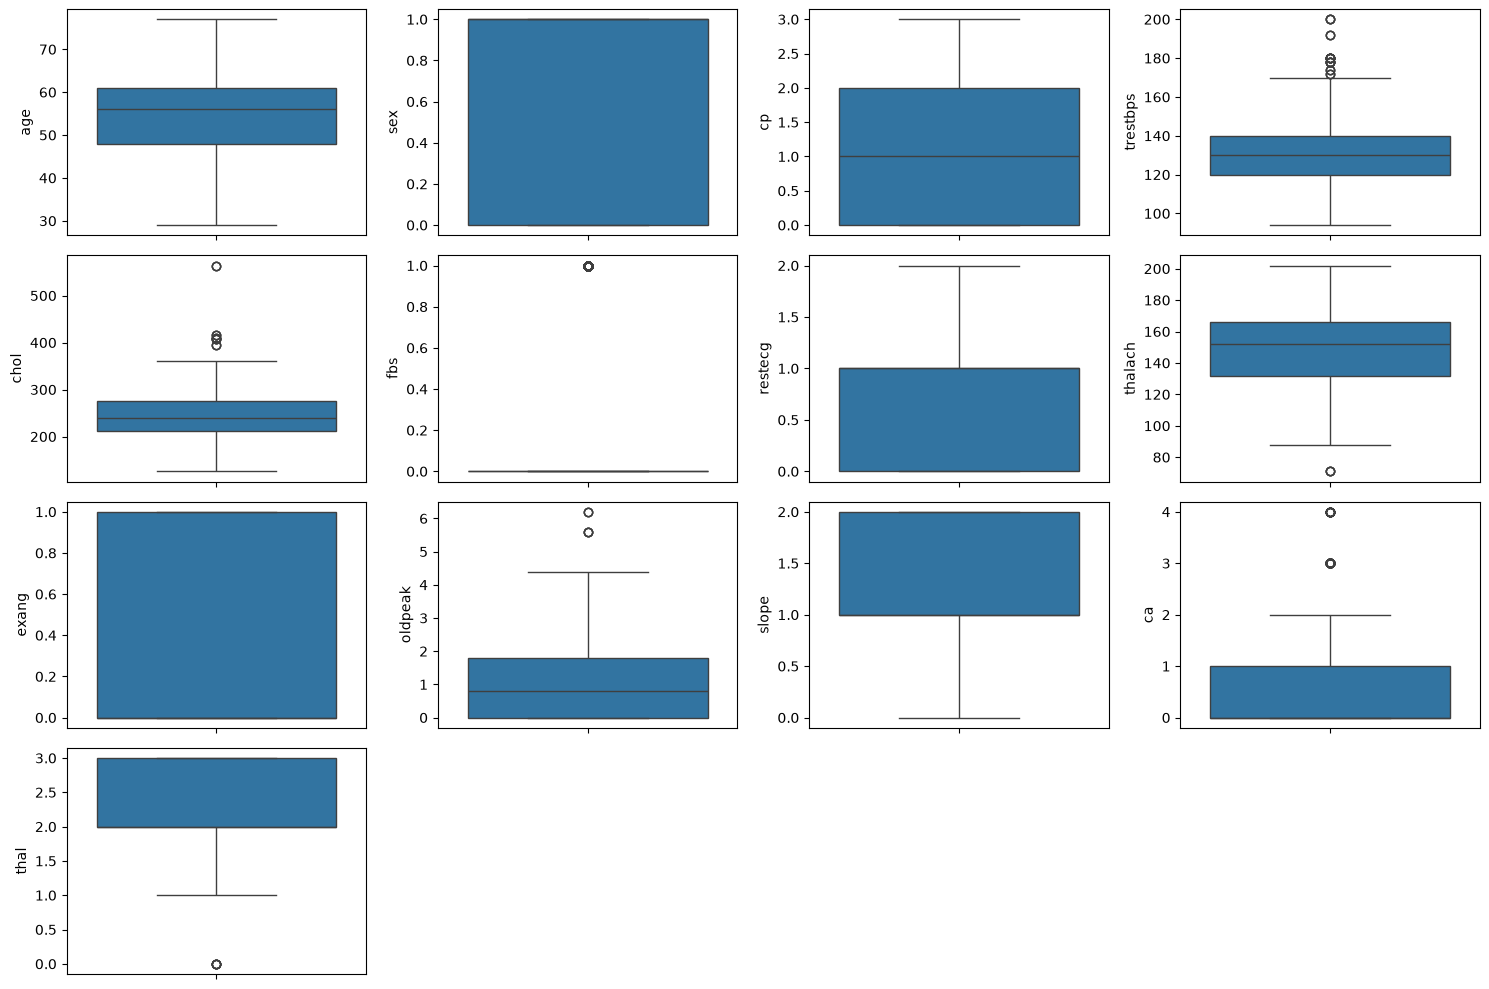

In [13]:
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns[:-1],1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

# Step 7: Split Data into Training and Testing Sets
The dataset is split into training and testing sets for model evaluation.

In [14]:
X = df.drop("target", axis=1)
y = df["target"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
688,56,0,0,200,288,1,0,133,1,4.0,0,2,3
477,57,1,2,128,229,0,0,150,0,0.4,1,1,3
336,57,1,2,150,126,1,1,173,0,0.2,2,1,3
960,52,0,2,136,196,0,0,169,0,0.1,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,57,1,0,130,131,0,1,115,1,1.2,1,1,3
367,48,1,1,110,229,0,1,168,0,1.0,0,0,3
393,62,0,0,160,164,0,0,145,0,6.2,0,3,3
777,53,1,0,123,282,0,1,95,1,2.0,1,2,3


In [17]:
y_train

4      0
688    0
477    0
336    1
960    1
      ..
882    0
367    0
393    0
777    0
489    1
Name: target, Length: 820, dtype: int64

In [18]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
756,64,1,0,120,246,0,0,96,1,2.2,0,1,2
353,57,1,0,110,201,0,1,126,1,1.5,1,0,1
929,60,1,0,130,206,0,0,132,1,2.4,1,2,3
129,57,1,0,140,192,0,1,148,0,0.4,1,0,1
591,63,0,0,108,269,0,1,169,1,1.8,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,67,1,0,120,237,0,1,71,0,1.0,1,0,2
218,46,1,0,140,311,0,1,120,1,1.8,1,2,3
564,56,1,0,132,184,0,0,105,1,2.1,1,1,1
426,54,0,2,160,201,0,1,163,0,0.0,2,1,2


In [19]:
y_test

756    0
353    1
929    0
129    1
591    0
      ..
378    0
218    0
564    0
426    1
904    1
Name: target, Length: 205, dtype: int64

In [20]:
X_train.shape

(820, 13)

In [21]:
X_test.shape

(205, 13)

# Step 8: Train Decision Tree

In [22]:
dt = DecisionTreeClassifier(random_state=42)

In [28]:
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# Step 9: Evaluate The Decision Tree

In [24]:
dt.score(X_test, y_test)

0.9853658536585366

In [25]:
dt.score(X_train, y_train)

1.0

# Step 10: Train KNeighborsClassifier

In [29]:
knn = KNeighborsClassifier(n_neighbors=5)

In [30]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


# Step 11: Evaluate KNN

In [31]:
knn.score(X_test, y_test)

0.697560975609756

In [32]:
knn.score(X_train, y_train)

0.9170731707317074

# Step 12: Train GaussianNB

In [34]:
gnb = GaussianNB()

In [35]:
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[399.,421.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.49,0.51]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.645e-06
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 13)","[[56.91, 0.81, 0.46,..., 1.16, 1.15, 2.56], [52.43, 0.58, 1.38,..., 1.58, 0.36, 2.14]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 13)","[[61.08, 0.15, 0.79,..., 0.33, 1.06, 0.45], [93.62, 0.24, 0.87,..., 0.36, 0.73, 0.2 ]]"


# Step 13: Evaluate GaussianNB

In [37]:
gnb.score(X_test, y_test)

0.8292682926829268

In [38]:
gnb.score(X_train, y_train)

0.8304878048780487

# Step 14: Decision Tree Cross-Validation 

In [39]:
cv_dt = cross_val_score(dt, X, y, cv = 10, scoring = "accuracy")

In [42]:
print("CV Scores : ", cv_dt)

CV Scores :  [1.         1.         1.         0.97087379 1.         1.
 1.         1.         1.         1.        ]


In [41]:
print("Mean Accuracy : ", cv_dt.mean())

Mean Accuracy :  0.9970873786407767


# Step 15: KNN Cross-Validation

In [43]:
cv_knn = cross_val_score(knn, X, y, cv = 10, scoring = "accuracy")

In [44]:
print("CV Scores : ", cv_knn)

CV Scores :  [0.76699029 0.78640777 0.74757282 0.77669903 0.77669903 0.76470588
 0.70588235 0.76470588 0.78431373 0.7254902 ]


In [45]:
print("Mean Accuracy : ", cv_knn.mean())

Mean Accuracy :  0.7599466971254522


# Step 16: GaussianNB Cross-Validation 

In [46]:
cv_gnb = cross_val_score(gnb, X, y, cv = 10, scoring = "accuracy")

In [47]:
print("CV Scores : ", cv_gnb)

CV Scores :  [0.85436893 0.88349515 0.87378641 0.76699029 0.84466019 0.88235294
 0.76470588 0.78431373 0.75490196 0.80392157]


In [48]:
print("Mean Accuracy : ", cv_gnb.mean())

Mean Accuracy :  0.821349704930516


# Step 17: Train Bagging Classifier

In [105]:
bag = BaggingClassifier(
    estimator = DecisionTreeClassifier(), 
    n_estimators = 100,
    random_state = 42
)

In [106]:
bag.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


# Step 18: Evaluate Bagging Classifier

In [107]:
bag.score(X_test, y_test)

1.0

In [108]:
bag.score(X_train, y_train)

1.0

# Step 19: Train Random Forest

In [110]:
rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
)

In [111]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

# Step 20: Evaluate Random Forest

In [112]:
rf.score(X_test, y_test)

1.0

In [113]:
rf.score(X_train, y_train)

1.0

# Step 21: Train AdaBoost Classifier

In [69]:
ada = AdaBoostClassifier(
    n_estimators = 100,
    random_state = 42
)

In [70]:
ada.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](100,)","[0.23,0.27,0.3 ,...,0.48,0.49,0.48]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[1.21,0.97,0.85,...,0.08,0.05,0.08]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](13,)","[0.1 ,0.04,0.06,...,0.03,0.09,0.05]"


# Step 22: Evaluate AdaBoost Classifier

In [71]:
ada.score(X_test, y_test)

0.8878048780487805

In [72]:
ada.score(X_train, y_train)

0.8963414634146342

# Step 23: Bagging Classifier Cross-Validation

In [114]:
cv_bag = cross_val_score(bag, X, y, cv = 10, scoring = "accuracy")

In [115]:
print("CV Scores : ", cv_bag)

CV Scores :  [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ]


In [116]:
print("Mean Accuracy : ", cv_bag.mean())

Mean Accuracy :  0.9970588235294118


# Step 24: Random Forest Cross-Validation

In [117]:
cv_rf = cross_val_score(rf, X, y, cv = 10, scoring = "accuracy")

In [118]:
print("CV Scores : ", cv_rf)

CV Scores :  [1.         1.         1.         1.         1.         1.
 1.         1.         0.97058824 1.        ]


In [119]:
print("Mean Accuracy : ", cv_rf.mean())

Mean Accuracy :  0.9970588235294118


# Step 25: AdaBoost Classifier Cross-Validation

In [91]:
cv_ada = cross_val_score(ada, X, y, cv = 10, scoring = "accuracy")

In [92]:
print("CV Scores : ", cv_ada)

CV Scores :  [0.87378641 0.93203883 0.91262136 0.86407767 0.87378641 0.94117647
 0.87254902 0.88235294 0.85294118 0.8627451 ]


In [93]:
print("Mean Accuracy : ", cv_ada.mean())

Mean Accuracy :  0.8868075385494004
